# 🚕 Táxis de NYC — Previsão de Demanda (PySpark) + Otimização de Frota

Este notebook é um **tour completo e comentado** de um projeto que une duas disciplinas
que raramente aparecem juntas:

1. **Machine Learning em escala**, com **PySpark / Spark MLlib**, para prever a demanda
   de táxis por zona e hora a partir de milhões de corridas.
2. **Pesquisa Operacional**, para transformar essa previsão em uma **decisão**: como
   alocar uma frota limitada entre as zonas para atender o máximo de demanda.

A narrativa é **prever → decidir**. Uma previsão só tem valor se levar a uma decisão
melhor — exatamente o que acontece em logística real (posicionamento de frota, alocação
de recursos).

> ⚠️ **Pré-requisitos:** este notebook exige **PySpark** (que precisa de um runtime Java,
> JDK 8/11/17) e pelo menos um arquivo Parquet da NYC TLC em `data/raw/` — veja
> `data/README.md`. A parte de otimização (Seção 5) roda mesmo sem Spark.

## 0. Preparação

Adicionamos `src/` ao caminho de importação para enxergar o pacote `taxi_pipeline`. Toda
a lógica vive nos módulos; o notebook apenas **orquestra e narra** — mesmo princípio do
projeto de previsão de demanda em máquina única.

In [1]:
%matplotlib inline

# --- Windows: Spark precisa de Java (JDK) e das libs nativas do Hadoop (winutils) ---
# Ajuste os caminhos abaixo se a sua instalacao for diferente. Em Linux/macOS,
# normalmente nada disto e necessario. Defina as variaveis ANTES de iniciar o Spark.
import os
import platform

if platform.system() == 'Windows':
    os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Microsoft\jdk-17.0.20.101-hotspot')
    os.environ.setdefault('HADOOP_HOME', r'C:\hadoop')
    hadoop_bin = os.path.join(os.environ['HADOOP_HOME'], 'bin')
    if hadoop_bin not in os.environ.get('PATH', ''):
        os.environ['PATH'] = os.environ.get('PATH', '') + os.pathsep + hadoop_bin
    print('JAVA_HOME  =', os.environ.get('JAVA_HOME'))
    print('HADOOP_HOME =', os.environ.get('HADOOP_HOME'))

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from taxi_pipeline import config, ingest, features, model, optimize
from taxi_pipeline.spark_session import get_spark
print('Pacote taxi_pipeline importado.')

JAVA_HOME  = C:\Program Files\Microsoft\jdk-17.0.20.101-hotspot
HADOOP_HOME = C:\hadoop
Pacote taxi_pipeline importado.


## 1. SparkSession — o motor distribuído

O **Spark** processa dados em paralelo, dividindo o trabalho em partições. Localmente,
`master='local[*]'` usa todos os núcleos da sua máquina; em um cluster, o mesmo código
escala para muitas máquinas sem alteração. É essa portabilidade que torna o Spark o
padrão de **big data**.

Um conceito central: o Spark é **lazy**. As transformações (filtros, agregações) só
montam um *plano*; nada é calculado até uma **ação** (`count`, `show`, `collect`, `write`).

In [2]:
#%pip install pyspark

In [3]:
spark = get_spark()
print('Spark', spark.version)
spark

Spark 4.2.0


## 2. Ingestão e limpeza

Lemos os arquivos Parquet da pasta `data/raw/`. O formato **Parquet** é colunar e
comprimido — ideal para análise, pois lê só as colunas necessárias.

`ingest.clean_trips()` aplica filtros de **qualidade de dados**: remove corridas com
distância implausível (zero/negativa ou absurdamente grande), zonas de embarque nulas e
contagens de passageiros inválidas. Tudo lazy — nenhuma linha é lida ainda.

In [4]:
trips_raw = ingest.read_trips(spark)
trips = ingest.clean_trips(trips_raw)

print('Colunas disponíveis:')
print(trips.columns)
# A ação .count() dispara o processamento distribuído:
print('\nTotal de corridas após limpeza:', trips.count())

Colunas disponíveis:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']

Total de corridas após limpeza: 2898408


## 3. Da corrida individual à demanda por zona-hora

O coração da engenharia de atributos: `features.build_zone_hour_demand()` usa um
**group by** distribuído para transformar milhões de corridas em uma tabela compacta —
para cada **zona** e cada **hora**, quantas corridas começaram ali. Essa agregação é o
tipo de operação em que o Spark brilha.

Em seguida, `add_calendar_features()` adiciona hora do dia, dia da semana e flag de fim de
semana — os principais fatores que explicam a demanda de táxis (horários de pico, fins de
semana).

In [5]:
demand = features.add_calendar_features(features.build_zone_hour_demand(trips))
demand.printSchema()
demand.orderBy('pickup_hour').show(5)

root
 |-- zone: long (nullable = true)
 |-- pickup_hour: timestamp (nullable = true)
 |-- demand: long (nullable = false)
 |-- hour: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- is_weekend: integer (nullable = false)

+----+-------------------+------+----+---------+----------+
|zone|        pickup_hour|demand|hour|dayofweek|is_weekend|
+----+-------------------+------+----+---------+----------+
| 132|2008-12-31 23:00:00|     1|  23|        4|         0|
| 132|2022-10-25 00:00:00|     1|   0|        3|         0|
| 265|2022-10-25 00:00:00|     1|   0|        3|         0|
| 132|2022-10-25 07:00:00|     1|   7|        3|         0|
| 132|2022-10-25 09:00:00|     1|   9|        3|         0|
+----+-------------------+------+----+---------+----------+
only showing top 5 rows


In [6]:
# Visão rápida: as zonas de maior demanda total no período
from pyspark.sql import functions as F
top_zonas = (demand.groupBy('zone')
                   .agg(F.sum('demand').alias('demanda_total'))
                   .orderBy(F.desc('demanda_total'))
                   .limit(10)
                   .toPandas())
top_zonas

,zone,demanda_total
0,132,153350
1,237,141789
2,236,131357
3,161,129740
4,186,105367
5,162,101257
6,142,95402
7,230,94794
8,138,87127
9,170,84365


## 4. Modelo de demanda com Spark MLlib

Usamos um **Gradient-Boosted Trees (GBT)** do Spark MLlib para prever a coluna `demand` a
partir de `zone`, `hour`, `dayofweek` e `is_weekend`.

Dois cuidados importantes, herdados do projeto de demanda em máquina única:

- **Divisão cronológica** (`model.chronological_split`): o começo da série vira treino e
  o final vira teste. Embaralhar vazaria o futuro no treino.
- **Vetor de atributos**: o MLlib espera as features numa única coluna-vetor, montada por
  um `VectorAssembler` (feito dentro de `model.py`).

Avaliamos com **RMSE**, **MAE** e **R²** no conjunto de teste.

In [7]:
train, test, cutoff = model.chronological_split(demand)
print('Corte temporal (treino | teste):', cutoff)

fitted = model.train_demand_model(train)
metrics = model.evaluate_model(fitted, test)
print('Métricas de demanda:', metrics)

Corte temporal (treino | teste): 2020-04-08 01:36:00
Métricas de demanda: {'RMSE': 83.99157349737833, 'MAE': 43.35409429660122, 'R2': -0.36320289403498696}


**Leitura:** o R² indica quanto da variação da demanda o modelo explica. Com poucos
atributos de calendário já se captura bastante estrutura (os picos horários são fortes).
Adicionar clima e feriados tende a melhorar — fica como extensão.

### Da previsão para a decisão

Agregamos a **demanda prevista por zona** no horizonte de teste. Esse vetor
`zona → demanda prevista` é exatamente a entrada do otimizador. Aqui termina o ML e começa
a Pesquisa Operacional.

In [8]:
from taxi_pipeline.features import FEATURE_COLUMNS, assemble_features

scored = fitted.transform(assemble_features(test, FEATURE_COLUMNS))
by_zone = (scored.groupBy('zone')
                 .agg(F.sum(F.greatest(F.col('prediction'), F.lit(0.0))).alias('pred'))
                 .orderBy(F.desc('pred'))
                 .limit(50)
                 .toPandas())

demand_by_zone = dict(zip(by_zone['zone'].astype(int), by_zone['pred'].astype(float)))
print('Zonas consideradas:', len(demand_by_zone))
by_zone.head()

Zonas consideradas: 50


,zone,pred
0,132,749.0
1,229,745.0
2,140,745.0
3,68,745.0
4,263,745.0


## 5. Otimização: alocação de frota (Pesquisa Operacional)

Temos uma frota limitada e precisamos decidir **quantos veículos posicionar em cada zona**
para cobrir o máximo da demanda prevista. Modelamos como um **Programa Linear Inteiro (PLI)**:

- **Variáveis:** `x_z` = veículos na zona *z* (inteiro); `s_z` = demanda atendida em *z*.
- **Objetivo:** maximizar a demanda total atendida, `∑ s_z`.
- **Restrições:**
  - orçamento de frota: `∑ x_z ≤ fleet_size`;
  - não atender além da demanda: `s_z ≤ demanda_z`;
  - capacidade dos veículos: `s_z ≤ trips_per_vehicle · x_z`;
  - limites por zona: `lb ≤ x_z ≤ ub`.

Resolvemos de forma **exata** com o solver CBC (via PuLP) e comparamos com uma
**heurística gulosa** (alocação proporcional à demanda) — como em qualquer estudo sério
de PO, o modelo exato precisa provar que vale a pena frente a uma regra simples.

In [9]:
exato = optimize.allocate_fleet(demand_by_zone, trips_per_vehicle=10.0)
guloso = optimize.greedy_baseline(demand_by_zone, trips_per_vehicle=10.0)

print('Status do solver :', exato.status)
print('Cobertura (exato ILP)  : {:.1%}'.format(exato.coverage))
print('Cobertura (guloso)     : {:.1%}'.format(guloso.coverage))
print('Ganho do exato sobre o guloso: {:.1f} pontos percentuais'.format(
    100 * (exato.coverage - guloso.coverage)))

Status do solver : Optimal
Cobertura (exato ILP)  : 13.7%
Cobertura (guloso)     : 13.3%
Ganho do exato sobre o guloso: 0.4 pontos percentuais


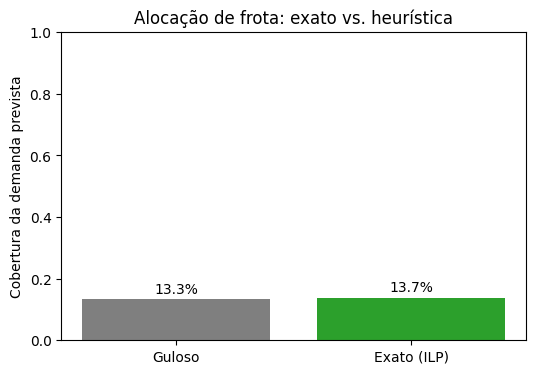

In [10]:
# Comparação visual da cobertura
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Guloso', 'Exato (ILP)'], [guloso.coverage, exato.coverage],
       color=['tab:gray', 'tab:green'])
ax.set_ylabel('Cobertura da demanda prevista')
ax.set_title('Alocação de frota: exato vs. heurística')
ax.set_ylim(0, 1)
for i, v in enumerate([guloso.coverage, exato.coverage]):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center')
plt.show()

In [11]:
# As 10 zonas que mais receberam veículos no plano ótimo
import pandas as pd
plano = (pd.DataFrame({'zona': list(exato.allocation.keys()),
                       'veiculos': list(exato.allocation.values()),
                       'demanda_prevista': [demand_by_zone[z] for z in exato.allocation]})
           .sort_values('veiculos', ascending=False)
           .head(10))
plano

,zona,veiculos,demanda_prevista
0,132,60,749.0
14,107,60,744.0
13,100,60,744.0
30,114,60,733.0
32,113,60,731.0
49,138,60,666.0
36,125,60,713.0
24,137,60,739.0
2,140,20,745.0
1,229,0,745.0


**Leitura:** o PLI concentra os veículos nas zonas de maior demanda prevista, respeitando
o teto por zona e o tamanho da frota. A cobertura do modelo exato é **sempre ≥** a do
guloso (garantido matematicamente e verificado nos testes do projeto). A diferença, mesmo
que de poucos pontos percentuais, representa corridas atendidas a mais — valor concreto na
escala de uma cidade.

## ✅ Conclusão

Percorremos um pipeline que vai do dado bruto distribuído até uma decisão operacional:

| Etapa | Tecnologia |
|---|---|
| Ingestão + limpeza | PySpark (Parquet, filtros) |
| Agregação zona-hora + features | Spark SQL |
| Modelo de demanda | Spark MLlib (GBT) |
| Alocação de frota | PLI exato (PuLP/CBC) + baseline guloso |

O ponto central é a integração: a **previsão** do ML vira a **entrada** do otimizador,
fechando o ciclo *prever → decidir*.

### Para evoluir
- Adicionar atributos de clima e feriados ao modelo de demanda.
- Incluir **custos de deslocamento** entre zonas (rebalanceamento), virando um problema de
  transporte mais rico.
- Rodar em vários meses de dados e em um cluster real para medir escalabilidade.

### Rodar tudo de uma vez
```bash
python scripts/run_pipeline.py
```

### Rodar os testes da otimização (sem Spark)
```bash
pytest -q
```

In [12]:
spark.stop()
print('SparkSession encerrada.')

SparkSession encerrada.
